<a href="https://colab.research.google.com/github/Kabilesh006/DEEPLEARNING/blob/main/EX2_Activation_Optimizer_Comparison_BreastCancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparative Study of Activation Functions and Optimizers

## Part A: Visualization of Activation Functions

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [18]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

x = np.linspace(-10, 10, 500)

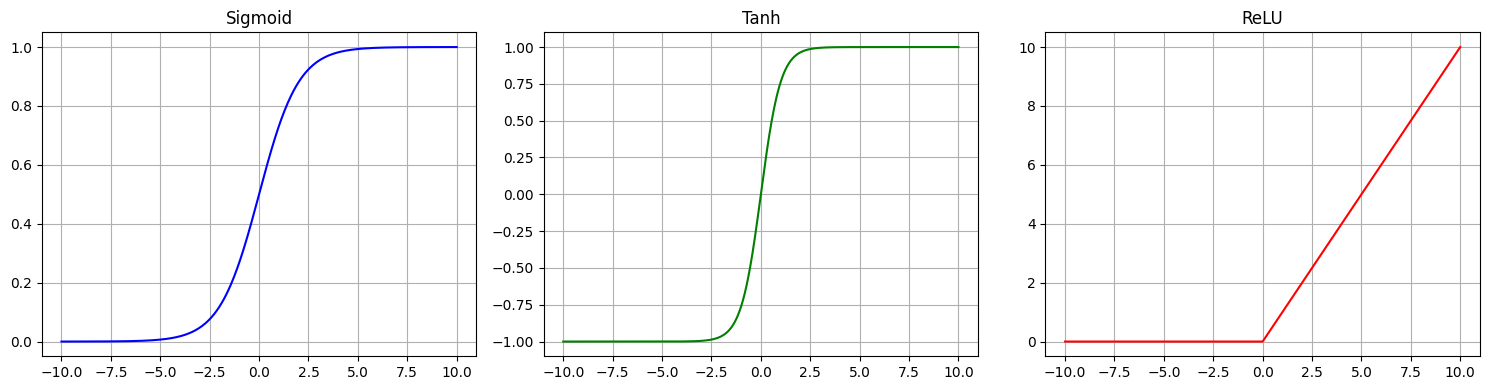

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x, sigmoid(x), color='blue')
axes[0].set_title('Sigmoid')
axes[0].grid(True)

axes[1].plot(x, tanh(x), color='green')
axes[1].set_title('Tanh')
axes[1].grid(True)

axes[2].plot(x, relu(x), color='red')
axes[2].set_title('ReLU')
axes[2].grid(True)

plt.tight_layout()
plt.show()

**Comparison Table**

| Property | Sigmoid | Tanh | ReLU |
|---|---|---|---|
| Output Range | (0, 1) | (-1, 1) | [0, ∞) |
| Zero-centered | No | Yes | No |
| Saturation | Both ends | Both ends | Only for x < 0 |
| Gradient behavior | Vanishes for large \|x\| | Vanishes for large \|x\| | Constant gradient for x > 0 |
| Computational cost | High (exp) | High (exp) | Low (max op) |
| Typical use | Output layer (binary) | Hidden layers (older nets) | Hidden layers (modern nets) |


## Data Loading and Preprocessing

In [20]:
data = load_breast_cancer()
X, y = data.data, data.target

print(X.shape, y.shape)
print(data.target_names)

(569, 30) (569,)
['malignant' 'benign']


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


## Part B: Performance Comparison of Activation Functions

In [22]:
def build_model(activation):
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(32, activation=activation),
        layers.Dense(16, activation=activation),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [23]:
activations = ['sigmoid', 'tanh', 'relu']
activation_histories = {}

for act in activations:
    print(f"Training with activation: {act}")
    model = build_model(act)
    history = model.fit(X_train, y_train,
                         validation_data=(X_test, y_test),
                         epochs=50, batch_size=32, verbose=0)
    activation_histories[act] = history.history
    val_acc = history.history['val_accuracy'][-1]
    print(f"Final validation accuracy: {val_acc:.4f}\n")

Training with activation: sigmoid
Final validation accuracy: 0.9561

Training with activation: tanh
Final validation accuracy: 0.9561

Training with activation: relu
Final validation accuracy: 0.9737



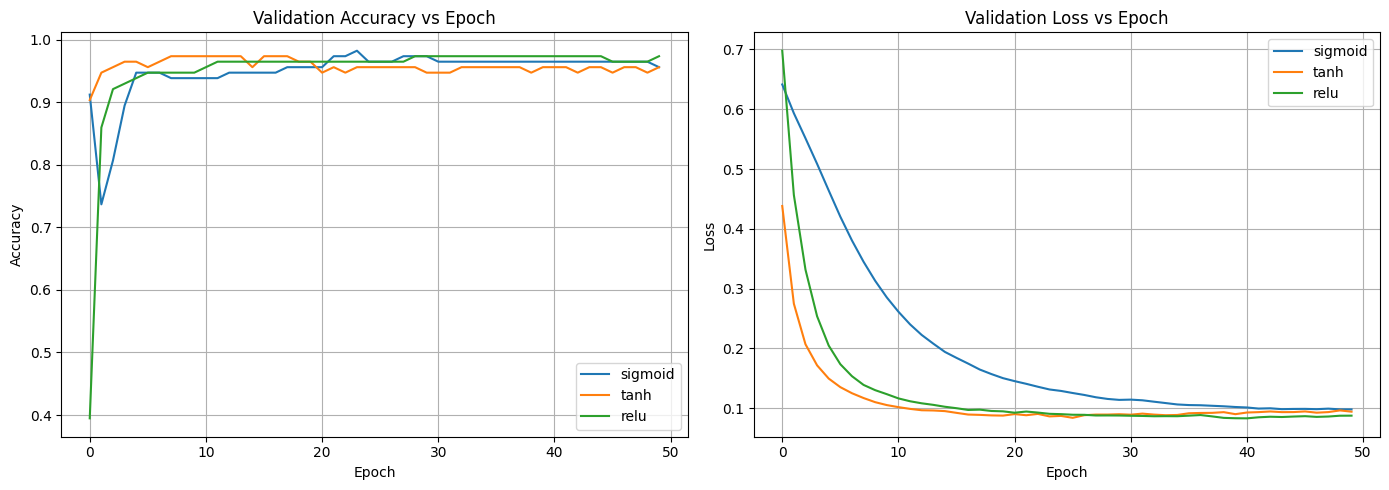

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for act in activations:
    axes[0].plot(activation_histories[act]['val_accuracy'], label=act)
    axes[1].plot(activation_histories[act]['val_loss'], label=act)

axes[0].set_title('Validation Accuracy vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Validation Loss vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [25]:
print(f"{'Activation':<10}{'Train Acc':<12}{'Val Acc':<12}{'Train Loss':<12}{'Val Loss':<12}")
for act in activations:
    h = activation_histories[act]
    print(f"{act:<10}{h['accuracy'][-1]:<12.4f}{h['val_accuracy'][-1]:<12.4f}{h['loss'][-1]:<12.4f}{h['val_loss'][-1]:<12.4f}")

ActivationTrain Acc   Val Acc     Train Loss  Val Loss    
sigmoid   0.9890      0.9561      0.0577      0.0981      
tanh      0.9912      0.9561      0.0264      0.0943      
relu      0.9934      0.9737      0.0232      0.0876      


**Observation:** ReLU typically converges fastest and reaches the highest validation accuracy since it avoids vanishing gradients for positive inputs, unlike Sigmoid and Tanh which saturate at both ends. On a small tabular dataset like this, differences between activations tend to be smaller than on image data, but ReLU still generally trains fastest.

## Part C: Comparison of Optimization Algorithms

In [26]:
def build_model_relu():
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

In [27]:
optimizers = {
    'SGD': keras.optimizers.SGD(learning_rate=0.01),
    'Momentum': keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSProp': keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': keras.optimizers.Adam(learning_rate=0.001)
}

optimizer_histories = {}

for name, opt in optimizers.items():
    print(f"Training with optimizer: {name}")
    model = build_model_relu()
    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    history = model.fit(X_train, y_train,
                         validation_data=(X_test, y_test),
                         epochs=50, batch_size=32, verbose=0)
    optimizer_histories[name] = history.history
    val_acc = history.history['val_accuracy'][-1]
    print(f"Final validation accuracy: {val_acc:.4f}\n")

Training with optimizer: SGD
Final validation accuracy: 0.9649

Training with optimizer: Momentum
Final validation accuracy: 0.9474

Training with optimizer: RMSProp
Final validation accuracy: 0.9737

Training with optimizer: Adam
Final validation accuracy: 0.9649



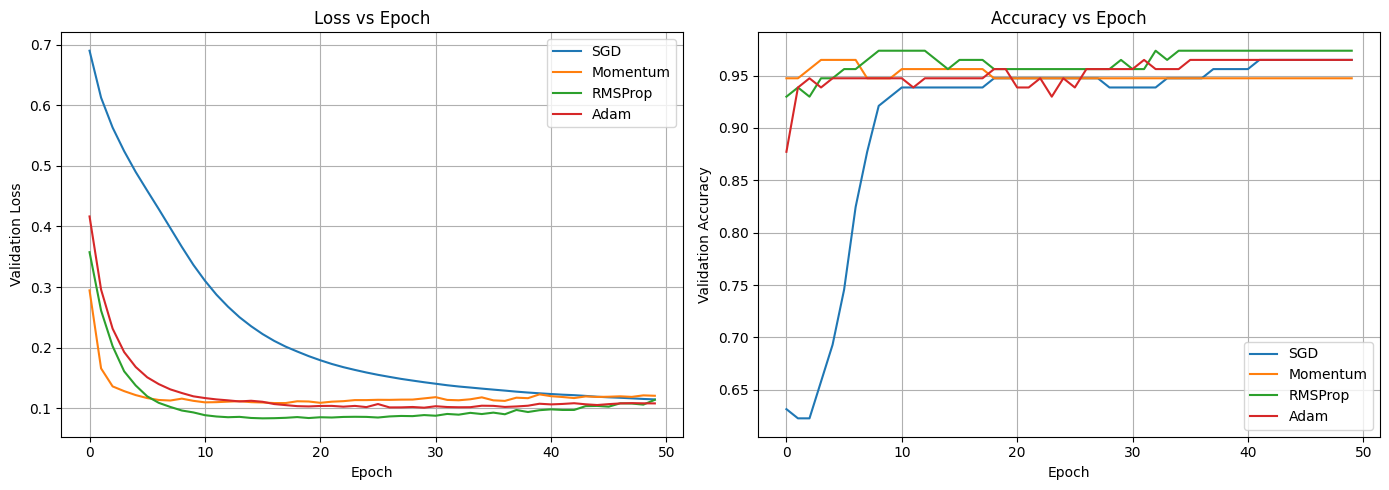

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in optimizers:
    axes[0].plot(optimizer_histories[name]['val_loss'], label=name)
    axes[1].plot(optimizer_histories[name]['val_accuracy'], label=name)

axes[0].set_title('Loss vs Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Accuracy vs Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [29]:
print(f"{'Optimizer':<12}{'Train Acc':<12}{'Val Acc':<12}{'Train Loss':<12}{'Val Loss':<12}")
for name in optimizers:
    h = optimizer_histories[name]
    print(f"{name:<12}{h['accuracy'][-1]:<12.4f}{h['val_accuracy'][-1]:<12.4f}{h['loss'][-1]:<12.4f}{h['val_loss'][-1]:<12.4f}")

Optimizer   Train Acc   Val Acc     Train Loss  Val Loss    
SGD         0.9824      0.9649      0.0745      0.1149      
Momentum    0.9978      0.9474      0.0106      0.1209      
RMSProp     0.9956      0.9737      0.0076      0.1143      
Adam        0.9934      0.9649      0.0162      0.1083      


**Observation:** Adam generally converges fastest and most stably, since it combines momentum with adaptive per-parameter learning rates. Plain SGD converges slowest, while Momentum and RMSProp fall in between.

PART D: DEEP LEARNING EXPERIMENT MANAGEMENT

In [30]:
# Mount Google Drive
import os
from google.colab import drive

drive.mount('/content/drive')
print('NAME: Kabileshwaran J\nROLL NO: 24BAD051')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
NAME: Kabileshwaran J
ROLL NO: 24BAD051


Import required libraries

In [31]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist

Load and Prepare the Dataset

In [32]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(60000, 784) / 255.0
X_test = X_test.reshape(10000, 784) / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


BUILD THE MODEL

In [33]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


COMPILE THE MODEL

In [34]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

TRAIN THE MODEL

In [35]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9285 - loss: 0.2439 - val_accuracy: 0.9598 - val_loss: 0.1258
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9666 - loss: 0.1056 - val_accuracy: 0.9724 - val_loss: 0.0899
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9772 - loss: 0.0728 - val_accuracy: 0.9737 - val_loss: 0.0784
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9822 - loss: 0.0554 - val_accuracy: 0.9735 - val_loss: 0.0848
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9852 - loss: 0.0444 - val_accuracy: 0.9756 - val_loss: 0.0805


SAVE THE MODEL

In [36]:
model.save('/content/drive/MyDrive/model.keras')
print("Model saved successfully!")

Model saved successfully!
